# Queda Livre: Modelagem Matemática e Implementação Computacional

Este notebook segue o roteiro proposto para o trabalho prático de modelagem matemática da Queda Livre, unindo teoria, programação e análise de resultados. Cada etapa é explicada em detalhes, com células Markdown e código Python, além de salvar os dados e gráficos gerados.

In [26]:
from pathlib import Path
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Diretório base do projeto (pasta do notebook)
base_dir = Path().resolve()

# Diretórios principais de dados
input_dir = base_dir / 'dados' / 'input'
output_dir = base_dir / 'dados' / 'output'

output_queda_livre_particula_dir = output_dir / 'queda_livre_particula'
output_queda_livre_corpo_rigido_dir = output_dir / 'queda_livre_corpo_rigido'
output_corpo_rigido_linear_dir = output_queda_livre_corpo_rigido_dir / 'linear'
output_corpo_rigido_quadratica_dir = output_queda_livre_corpo_rigido_dir / 'quadratica'
output_acuracia_dir = output_dir / 'acuracia'

# Diretórios principais de gráficos
graficos_dir = base_dir / 'graficos'
graficos_queda_livre_particula_dir = graficos_dir / 'queda_livre_particula'
graficos_queda_livre_corpo_rigido_dir = graficos_dir / 'queda_livre_corpo_rigido'
graficos_queda_livre_corpo_rigido_linear_dir = graficos_queda_livre_corpo_rigido_dir / 'linear'
graficos_queda_livre_corpo_rigido_quadratica_dir = graficos_queda_livre_corpo_rigido_dir / 'quadratica'


graficos_comparativo_dir = graficos_dir / 'comparativo'
graficos_acuracia_dir = graficos_dir / 'acuracia'

# Lista de todas as pastas a serem criadas
pastas = [
    input_dir, output_dir, output_queda_livre_particula_dir, output_queda_livre_corpo_rigido_dir,
    output_corpo_rigido_linear_dir, output_corpo_rigido_quadratica_dir,
    output_acuracia_dir,

    graficos_dir, graficos_queda_livre_particula_dir, graficos_queda_livre_corpo_rigido_dir,
    graficos_queda_livre_corpo_rigido_linear_dir, graficos_queda_livre_corpo_rigido_quadratica_dir,
    graficos_comparativo_dir, graficos_acuracia_dir
]

# Função para remover pasta
def remover_pasta(pasta):
    if pasta.exists() and pasta.is_dir():
        shutil.rmtree(pasta)
        print(f'Pasta removida: {pasta}')

# APAGA TODAS AS PASTAS ANTES DE CRIAR
for pasta in pastas:
    remover_pasta(pasta)

# CRIA TODAS AS PASTAS DO ZERO
for pasta in pastas:
    pasta.mkdir(exist_ok=True, parents=True)

print('\nPastas criadas novamente:')
for pasta in pastas:
    print(pasta)

# Função para salvar DataFrame
def salvar_dados(df, pasta_destino, nome_arquivo):
    saida_csv = pasta_destino / nome_arquivo
    df.to_csv(saida_csv, index=False, float_format='%.4f')
    print(f'Resultado salvo em: {saida_csv}')

Pasta removida: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input
Pasta removida: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output
Pasta removida: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\graficos

Pastas criadas novamente:
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear
D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica
D:\GitHub\Douto

In [27]:
# Função para salvar DataFrame de saída normalmente
def salvar_dados(df, pasta_destino, nome_arquivo):
    saida_csv = os.path.join(pasta_destino, nome_arquivo) if isinstance(pasta_destino, str) else pasta_destino / nome_arquivo
    df.to_csv(saida_csv, index=False, float_format='%.4f')
    print(f'Resultado salvo em: {saida_csv}')

## 1. Criação das Funções

### 1.1 Função para simular a queda livre usando o método de Euler

In [28]:
def simula_queda_livre_particula(H, V, g, dt):
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g]   # aceleração inicial

    while x[-1] > 0:
        # aceleração constante
        a_atual = -g

        # atualiza velocidade
        v.append(v[-1] + a_atual * dt)

        # atualiza posição com velocidade ATUALIZADA
        x.append(x[-1] + v[-1] * dt)

        # atualiza tempo
        t.append(t[-1] + dt)

        # salva aceleração
        a.append(a_atual)

        # impacto no solo
        if x[-1] <= 0:
            x[-1] = 0
            break

    return pd.DataFrame({
        'tempo': t,
        'posicao': x,
        'velocidade': v,
        'aceleracao': a
    })

### 1.2. Função para Modelagem de corpo rígido em queda livre com resistência 

#### 1.2.2 Função com resistência linear

In [29]:
def simula_queda_livre_corpo_rigido_linear(H, V, g, dt, k):
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g - k * v[-1]]   # aceleração inicial

    while x[-1] > 0:

        # calcula aceleração atual
        a_atual = -g - k * v[-1]

        # atualiza velocidade
        v.append(v[-1] + a_atual * dt)

        # atualiza posição com velocidade ATUALIZADA
        x.append(x[-1] + v[-1] * dt)

        # atualiza tempo
        t.append(t[-1] + dt)

        # salva aceleração
        a.append(a_atual)

        # impacto no solo
        if x[-1] <= 0:
            x[-1] = 0
            break

    return pd.DataFrame({
        'tempo': t,
        'posicao': x,
        'velocidade': v,
        'aceleracao': a
    })

#### 1.2.2 Função com resistência quadrática

In [30]:
def simula_queda_livre_corpo_rigido_quadratica(H, V, g, dt, c):
    t = [0.0]
    x = [H]
    v = [V]
    a = [-g - c * v[-1] * abs(v[-1])]   # aceleração inicial

    while x[-1] > 0:

        # calcula aceleração atual
        a_atual = -g - c * v[-1] * abs(v[-1])

        # atualiza velocidade
        v.append(v[-1] + a_atual * dt)

        # atualiza posição com velocidade ATUALIZADA
        x.append(x[-1] + v[-1] * dt)

        # atualiza tempo
        t.append(t[-1] + dt)

        # salva aceleração
        a.append(a_atual)

        # impacto no solo
        if x[-1] <= 0:
            x[-1] = 0
            break

    return pd.DataFrame({
        'tempo': t,
        'posicao': x,
        'velocidade': v,
        'aceleracao': a
    })

### 1.4. Função para Apresentação dos Gráficos: Posição, Velocidade, Aceleração em função do Tempo e acurácia

In [31]:
def plotar_grafico_posicao_tempo(resultados, dt_list, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        x = resultados[dt]['x']
        plt.plot(t, x, label=f'dt = {dt} s')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Posição (m)')
    plt.title(f'Posição x Tempo ({titulo})')
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()


In [32]:
def plotar_grafico_velocidade_tempo(resultados, dt_list, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        v = resultados[dt]['v']
        plt.plot(t, v, label=f'dt = {dt} s')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Velocidade (m/s)')
    plt.title(f'Velocidade x Tempo ({titulo})')
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()


In [33]:
def plotar_grafico_aceleracao_tempo(resultados, dt_list, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(8,5))
    for dt in dt_list:
        t = resultados[dt]['t']
        a = resultados[dt]['a']
        plt.plot(t, a, label=f'dt = {dt} s')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Aceleração (m/s²)')
    plt.title(f'Aceleração x Tempo ({titulo})')
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()


In [34]:
def plotar_comparativo_modelos_posicao(dt, modelos_arquivos, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(10, 6))

    for modelo, arquivo in modelos_arquivos.items():
        df = pd.read_csv(arquivo)
        plt.plot(df['tempo'], df['posicao'], label=modelo)

    plt.xlabel('Tempo (s)')
    plt.ylabel('Posição (m)')
    plt.title(f'Comparativo de Posição - dt = {dt} ({titulo})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

In [35]:
def plotar_comparativo_modelos_velocidade(dt, modelos_arquivos, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(10, 6))

    for modelo, arquivo in modelos_arquivos.items():
        df = pd.read_csv(arquivo)
        plt.plot(df['tempo'], df['velocidade'], label=modelo)

    plt.xlabel('Tempo (s)')
    plt.ylabel('Velocidade (m/s)')
    plt.title(f'Comparativo de Velocidade - dt = {dt} ({titulo})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

In [36]:
def plotar_comparativo_modelos_aceleracao(dt, modelos_arquivos, graficos_dir, titulo, nome_arquivo):
    plt.figure(figsize=(10, 6))

    for modelo, arquivo in modelos_arquivos.items():
        df = pd.read_csv(arquivo)

        if 'aceleracao' in df.columns:
            aceleracao = df['aceleracao']
        else:
            # cálculo numérico da aceleração
            v = df['velocidade'].values
            t = df['tempo'].values
            aceleracao = [(v[i+1] - v[i]) / (t[i+1] - t[i]) for i in range(len(v)-1)]
            aceleracao.append(aceleracao[-1])  # igualar tamanhos

        plt.plot(df['tempo'], aceleracao, label=modelo)

    plt.xlabel('Tempo (s)')
    plt.ylabel('Aceleração (m/s²)')
    plt.title(f'Comparativo de Aceleração - dt = {dt} ({titulo})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

### 1.5. Função Esutdo da acurácia Acurácia em Função do Tamanhao do Passo

In [37]:

def vfinal_analitico_particula(V, g, t):
    return V - g * t

def erro_relativo(v_num, v_ref):
    return abs((v_num - v_ref) / v_ref) if v_ref != 0 else np.nan


def acuracia_particula(H, V, g, dt_list):
    v_finais = []
    t_finais = []
    v_analiticos = []
    erros = []

    for dt in dt_list:
        df = simula_queda_livre_particula(H, V, g, dt)

        t_final = df['tempo'].iloc[-1]
        v_final = df['velocidade'].iloc[-1]
        v_ana   = vfinal_analitico_particula(V, g, t_final)

        v_finais.append(v_final)
        t_finais.append(t_final)
        v_analiticos.append(v_ana)
        erros.append(erro_relativo(v_final, v_ana))

    return v_finais, t_finais, v_analiticos, erros

def acuracia_modelo_com_resistencia(simulador, H, V, g, dt_list, dt_ref, extra_params):
    # referência com passo bem pequeno
    df_ref = simulador(H, V, g, dt_ref, *extra_params)
    v_ref  = df_ref['velocidade'].iloc[-1]

    v_finais = []
    t_finais = []
    v_refs   = []
    erros    = []

    for dt in dt_list:
        df = simulador(H, V, g, dt, *extra_params)

        t_final = df['tempo'].iloc[-1]
        v_final = df['velocidade'].iloc[-1]

        v_finais.append(v_final)
        t_finais.append(t_final)
        v_refs.append(v_ref)
        erros.append(erro_relativo(v_final, v_ref))

    return v_finais, t_finais, v_refs, erros

def acuracia_modelo_com_resistencia(simulador, H, V, g, dt_list, dt_ref, extra_params):
    df_ref = simulador(H, V, g, dt_ref, *extra_params)
    v_ref  = df_ref['velocidade'].iloc[-1]

    v_finais, t_finais, v_refs, erros = [], [], [], []

    for dt in dt_list:
        df = simulador(H, V, g, dt, *extra_params)
        t_final = df['tempo'].iloc[-1]
        v_final = df['velocidade'].iloc[-1]

        v_finais.append(v_final)
        t_finais.append(t_final)
        v_refs.append(v_ref)
        erros.append(erro_relativo(v_final, v_ref))

    return v_finais, t_finais, v_refs, erros

def acuracia_particula_tempo(H, V, g, dt_list):
    t_ref = np.sqrt(2 * H / g)  # tempo analítico

    t_finais = []
    erros = []

    for dt in dt_list:
        df = simula_queda_livre_particula(H, V, g, dt)
        t_final = df['tempo'].iloc[-1]

        t_finais.append(t_final)
        erros.append(abs((t_final - t_ref) / t_ref))

    return t_finais, erros

def acuracia_resistencia_tempo(simulador, H, V, g, dt_list, dt_ref, extra_params):
    df_ref = simulador(H, V, g, dt_ref, *extra_params)
    t_ref = df_ref['tempo'].iloc[-1]

    t_finais = []
    erros = []

    for dt in dt_list:
        df = simulador(H, V, g, dt, *extra_params)
        t_final = df['tempo'].iloc[-1]

        t_finais.append(t_final)
        erros.append(abs((t_final - t_ref) / t_ref))

    return t_finais, erros


def simula_acuracia_parametrizada(H, V, g, dt_list, output_acuracia_dir, k, c, dt_ref_resistencia=1e-5):

    # --- PARTÍCULA ---
    t_finais, erros = acuracia_particula_tempo(H, V, g, dt_list)

    df_sem = pd.DataFrame({
        'dt (s)': dt_list,
        'tempo_final (s)': t_finais,
        'erro_relativo': erros
    })
    salvar_dados(df_sem, output_acuracia_dir, 'acuracia_sem_resistencia.csv')

    # --- LINEAR ---
    t_finais, erros_lin = acuracia_resistencia_tempo(
        simula_queda_livre_corpo_rigido_linear,
        H, V, g, dt_list, dt_ref_resistencia, [k]
    )

    df_lin = pd.DataFrame({
        'dt (s)': dt_list,
        'tempo_final (s)': t_finais,
        'erro_relativo': erros_lin
    })
    salvar_dados(df_lin, output_acuracia_dir, 'acuracia_com_resistencia_linear.csv')

    # --- QUADRÁTICA ---
    t_finais, erros_quad = acuracia_resistencia_tempo(
        simula_queda_livre_corpo_rigido_quadratica,
        H, V, g, dt_list, dt_ref_resistencia, [c]
    )

    df_quad = pd.DataFrame({
        'dt (s)': dt_list,
        'tempo_final (s)': t_finais,
        'erro_relativo': erros_quad
    })
    salvar_dados(df_quad, output_acuracia_dir, 'acuracia_com_resistencia_quadratica.csv')

In [38]:
import matplotlib.pyplot as plt
import os

def plotar_acuracia_dt(caminho_csv, titulo, nome_arquivo, graficos_dir):
    df = pd.read_csv(caminho_csv)

    dt = df['dt (s)']
    erro = df['erro_relativo']

    plt.figure(figsize=(8, 6))
    plt.loglog(dt, erro, marker='o', linewidth=2)

    plt.xlabel('Passo de tempo Δt (s)')
    plt.ylabel('Erro relativo')
    plt.title(titulo)
    plt.grid(True, which='both', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

In [39]:
def plotar_acuracia_comparativa(output_acuracia_dir, graficos_dir, nome_arquivo):
    import matplotlib.pyplot as plt
    import pandas as pd
    import os

    df_part = pd.read_csv(output_acuracia_dir / 'acuracia_sem_resistencia.csv')
    df_lin  = pd.read_csv(output_acuracia_dir / 'acuracia_com_resistencia_linear.csv')
    df_quad = pd.read_csv(output_acuracia_dir / 'acuracia_com_resistencia_quadratica.csv')

    plt.figure(figsize=(9, 6))

    plt.loglog(df_part['dt (s)'], df_part['erro_relativo'], marker='o', label='Partícula (sem resistência)')
    plt.loglog(df_lin['dt (s)'],  df_lin['erro_relativo'],  marker='s', label='Linear (Stokes)')
    plt.loglog(df_quad['dt (s)'], df_quad['erro_relativo'], marker='^', label='Quadrática (Arrasto)')

    plt.xlabel('Passo de tempo Δt (s)')
    plt.ylabel('Erro relativo')
    plt.title('Comparação da Acurácia — Partícula × Linear × Quadrática')
    plt.grid(True, which='both', linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()

    plt.savefig(os.path.join(graficos_dir, nome_arquivo))
    plt.show()

In [40]:
def gerar_tabela_acuracia(output_acuracia_dir):
    df_part = pd.read_csv(output_acuracia_dir / 'acuracia_sem_resistencia.csv')
    df_lin  = pd.read_csv(output_acuracia_dir / 'acuracia_com_resistencia_linear.csv')
    df_quad = pd.read_csv(output_acuracia_dir / 'acuracia_com_resistencia_quadratica.csv')

    tabela = pd.DataFrame({
        'dt (s)': df_part['dt (s)'],
        'Erro Partícula': df_part['erro_relativo'],
        'Erro Linear': df_lin['erro_relativo'],
        'Erro Quadrática': df_quad['erro_relativo']
    })

    return tabela

## 2. Implementação dos Modelos
### 2.1. Parâmetros

In [41]:
# ============================================================
#  PARÂMETROS BÁSICOS DO MOVIMENTO
# ============================================================

H = 10000.0      # altura inicial (m)
V = 0.0          # velocidade inicial (m/s)
g = 9.81         # gravidade (m/s²)


# ============================================================
#  PASSOS DE TEMPO PARA ESTUDO DE ACURÁCIA
# ============================================================

# Passos de tempo em escala logarítmica (correto para acurácia)
dt_list = np.logspace(-4, 0, 9)  
# Gera: [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]


# ============================================================
#  MODELO DE RESISTÊNCIA LINEAR (Lei de Stokes)
# ============================================================

def calcular_k_stokes(eta, r):
    """
    Calcula o coeficiente de resistência linear k pela Lei de Stokes.
    k = 6 * pi * eta * r
    """
    import math
    return 6 * math.pi * eta * r

eta = 1.8e-5   # viscosidade dinâmica do ar (Pa·s)
r   = 0.01     # raio da esfera (m)

k = calcular_k_stokes(eta, r)
print("k (Stokes) =", k)


# ============================================================
#  MODELO DE RESISTÊNCIA QUADRÁTICA (Arrasto Aerodinâmico)
# ============================================================

def calcular_c_aerodinamico(rho, Cd, A):
    """
    Calcula o coeficiente de resistência quadrática c.
    c = 0.5 * rho * Cd * A
    """
    return 0.5 * rho * Cd * A

m   = 1.0     # massa do corpo (kg)
Cd  = 0.47    # coeficiente de arrasto (esfera)
A   = 0.01    # área frontal (m²)
rho = 1.225   # densidade do ar (kg/m³)

c = calcular_c_aerodinamico(rho, Cd, A)
print("c (quadrático) =", c)


k (Stokes) = 3.392920065876977e-06
c (quadrático) = 0.00287875


In [42]:
# ============================================================
# Construção da tabela de parâmetros (formato padrão)
# ============================================================

def construir_tabela_parametros(parametros):
    return pd.DataFrame([
        {
            "Parâmetro": p,
            "Descrição": desc,
            "Valor": val,
            "Unidade": unidade
        }
        for p, (desc, val, unidade) in parametros.items()
    ])


# ============================================================
# Tabela – Queda Livre (sem resistência)
# ============================================================

param_queda_livre = {
    "H":  ("Altura Inicial",            H,   "m"),
    "V":  ("Velocidade Inicial",        V,   "m/s"),
    "g":  ("Aceleração da Gravidade",   g,   "m/s²"),
}

df_param_queda_livre = construir_tabela_parametros(param_queda_livre)
salvar_dados(df_param_queda_livre, input_dir, "parametros_queda_livre.csv")


# ============================================================
# Tabela – Resistência Linear Completa (Lei de Stokes)
# ============================================================

param_linear_completo = {
    "H":   ("Altura Inicial",            H,    "m"),
    "V":   ("Velocidade Inicial",        V,    "m/s"),
    "g":   ("Aceleração da Gravidade",   g,    "m/s²"),
    "m":   ("Massa",                     m,    "kg"),
    "eta": ("Viscosidade do Ar",         eta,  "Pa·s"),
    "r":   ("Raio da Esfera",            r,    "m"),
    "k":   ("Coeficiente Linear (Stokes)", k,  "1/s"),
}

df_param_linear_completo = construir_tabela_parametros(param_linear_completo)
salvar_dados(df_param_linear_completo, input_dir, "parametros_linear.csv")


# ============================================================
# Tabela – Resistência Quadrática
# ============================================================

param_quadratica_completo = {
    "H":    ("Altura Inicial",            H,    "m"),
    "V":    ("Velocidade Inicial",        V,    "m/s"),
    "g":    ("Aceleração da Gravidade",   g,    "m/s²"),
    "m":    ("Massa",                     m,    "kg"),
    "Cd":   ("Coeficiente de Arrasto",    Cd,   "-"),
    "A":    ("Área Frontal",              A,    "m²"),
    "rho":  ("Densidade do Ar",           rho,  "kg/m³"),
    "c":    ("Coeficiente Quadrático",    c,    "kg/m"),
}

df_param_quadratica_completo = construir_tabela_parametros(param_quadratica_completo)
salvar_dados(df_param_quadratica_completo, input_dir, "parametros_quadratica.csv")


# ============================================================
# Tabela – Estudo de Acurácia
# ============================================================

param_acuracia = {
    "H":        ("Altura Inicial",            H,        "m"),
    "V":        ("Velocidade Inicial",        V,        "m/s"),
    "g":        ("Aceleração da Gravidade",   g,        "m/s²"),
    "k":        ("Coeficiente Linear",        k,        "1/s"),
    "c":        ("Coeficiente Quadrático",    c,        "kg/m"),
    "dt_list":  ("Passos de Tempo Testados",  dt_list,  "s"),
}

df_param_acuracia = construir_tabela_parametros(param_acuracia)
salvar_dados(df_param_acuracia, input_dir, "parametros_acuracia.csv")

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\parametros_queda_livre.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\parametros_linear.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\parametros_quadratica.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\input\parametros_acuracia.csv


### 2.2. Implementação do Modelo de uma Partícula em Queda Livre

Neste passo, vamos implementar o modelo discreto da queda livre usando o método de Euler. O objetivo é calcular, passo a passo, a posição e a velocidade de uma pedra até ela atingir o solo.

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_0001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_00031622776601683794.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_0031622776601683794.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_031

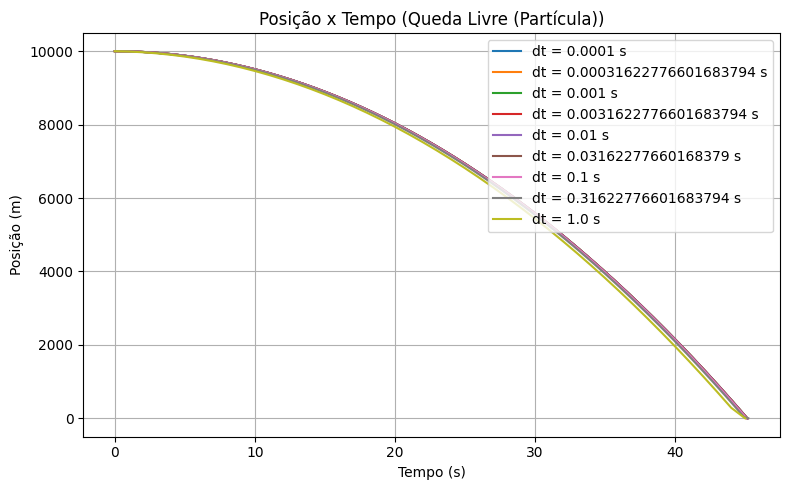

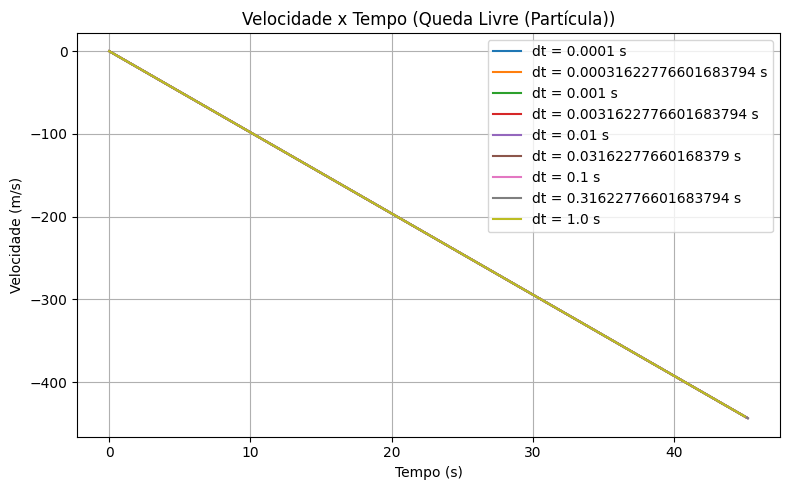

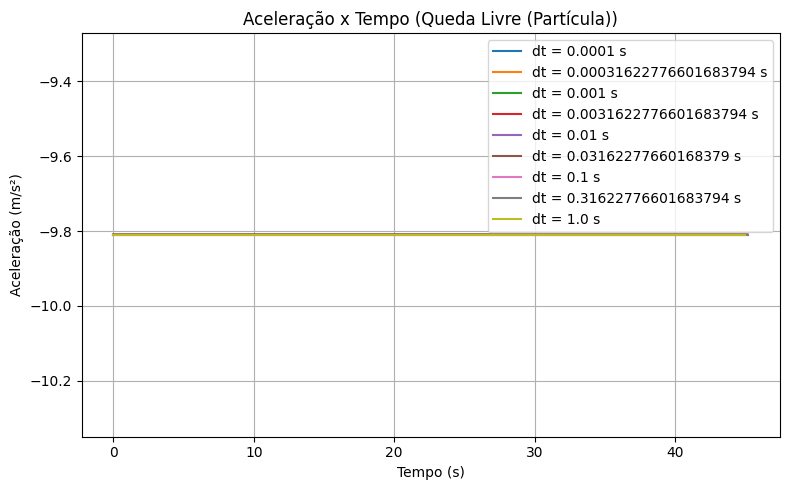

In [43]:
resultados_csv = {}

for dt in dt_list:
    # Executa a simulação
    df = simula_queda_livre_particula(H, V, g, dt)

    # CORREÇÃO: Aceleração constante com sinal negativo (a = -g)
    # Reflete o modelo físico apontado na sua fundamentação teórica.
    df["aceleracao"] = -g

    # Armazena os resultados
    resultados_csv[dt] = {
        't': df['tempo'].tolist(),
        'x': df['posicao'].tolist(),
        'v': df['velocidade'].tolist(),
        'a': df['aceleracao'].tolist()
    }

    # Nome do arquivo
    nome_arquivo = f"saida_queda_livre_dt_{str(dt).replace('.', '_')}.csv"

    # Salva o CSV
    salvar_dados(df, output_queda_livre_particula_dir, nome_arquivo)


# ============================================================
# Gráficos
# ============================================================

plotar_grafico_posicao_tempo(
    resultados_csv,
    dt_list,
    graficos_queda_livre_particula_dir,
    "Queda Livre (Partícula)",
    "grafico_posicao_tempo_multidt.png"
)

plotar_grafico_velocidade_tempo(
    resultados_csv,
    dt_list,
    graficos_queda_livre_particula_dir,
    "Queda Livre (Partícula)",
    "grafico_velocidade_tempo_multidt.png"
)

plotar_grafico_aceleracao_tempo(
    resultados_csv,
    dt_list,
    graficos_queda_livre_particula_dir,
    "Queda Livre (Partícula)",
    "grafico_aceleracao_tempo_multidt.png"
)


### 2.3. Implementação do Modelo Corpo Rígido em Queda Livre


#### 2.3.1. Simulação com Resistência Linear

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear\saida_queda_livre_linear_dt_0_0001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear\saida_queda_livre_linear_dt_0_00031622776601683794.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear\saida_queda_livre_linear_dt_0_001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear\saida_queda_livre_linear_dt_0_0031622776601683794.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear\saida_queda_livre_linear_dt_0_01.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematic

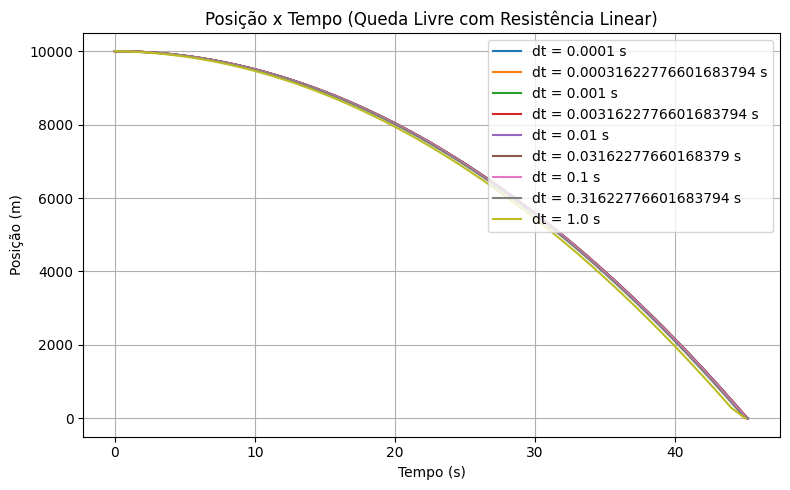

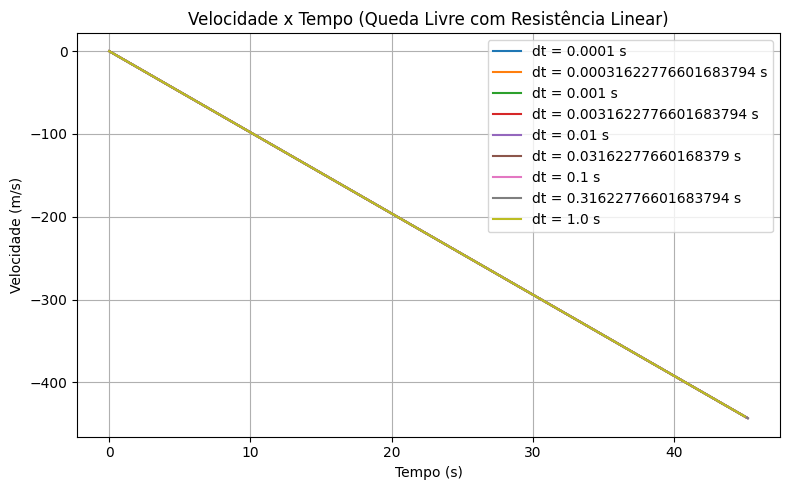

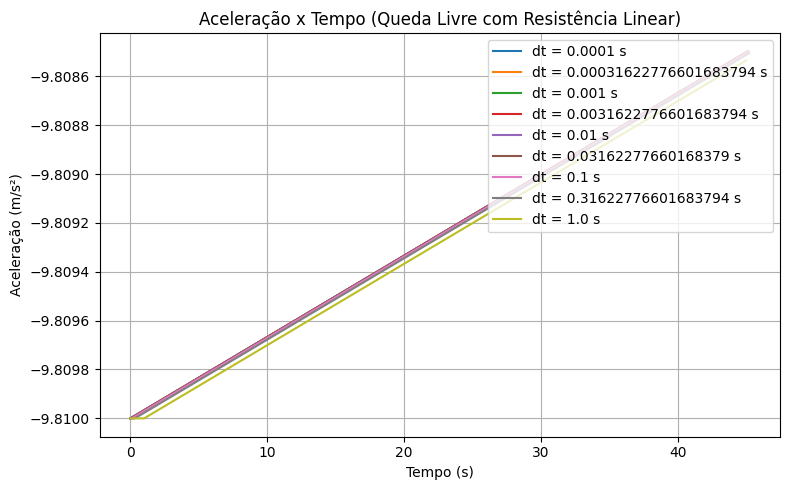

In [44]:
# Simulação, salvamento e preparação para plotagem (tudo junto)
resultados_csv_linear = {}

for dt in dt_list:
    df_linear = simula_queda_livre_corpo_rigido_linear(H, V, g, dt, k)
    
    # Armazena resultados
    resultados_csv_linear[dt] = {
        't': df_linear['tempo'].tolist(),
        'x': df_linear['posicao'].tolist(),
        'v': df_linear['velocidade'].tolist(),
        'a': df_linear['aceleracao'].tolist()
    }

    # Nome do arquivo
    nome_arquivo = (
        f"saida_queda_livre_linear_dt_{str(dt).replace('.', '_')}.csv"
    )

    # Salva CSV
    salvar_dados(df_linear, output_corpo_rigido_linear_dir, nome_arquivo)



# ============================================================
# Gráficos
# ============================================================

plotar_grafico_posicao_tempo(
    resultados_csv_linear,
    dt_list,
    graficos_queda_livre_corpo_rigido_linear_dir,
    "Queda Livre com Resistência Linear",
    "grafico_posicao_tempo_linear.png"
)


plotar_grafico_velocidade_tempo(
    resultados_csv_linear,
    dt_list,
    graficos_queda_livre_corpo_rigido_linear_dir,
    "Queda Livre com Resistência Linear",
    "grafico_velocidade_tempo_linear.png"
)


plotar_grafico_aceleracao_tempo(
    resultados_csv_linear,
    dt_list,
    graficos_queda_livre_corpo_rigido_linear_dir,
    "Queda Livre com Resistência Linear",
    "grafico_aceleracao_tempo_linear.png"
)

#### 2.3.1. Simulação com Resistência Quadrática

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica\saida_queda_livre_quadratica_dt_0_0001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica\saida_queda_livre_quadratica_dt_0_00031622776601683794.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica\saida_queda_livre_quadratica_dt_0_001.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica\saida_queda_livre_quadratica_dt_0_0031622776601683794.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica\saida_queda_livre_quadratica_dt_0_01.csv
Resultado salvo em: D:\GitHub\Do

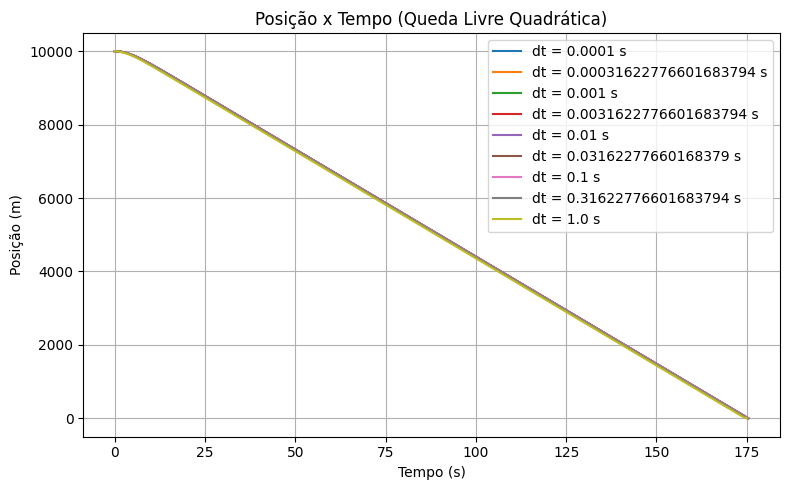

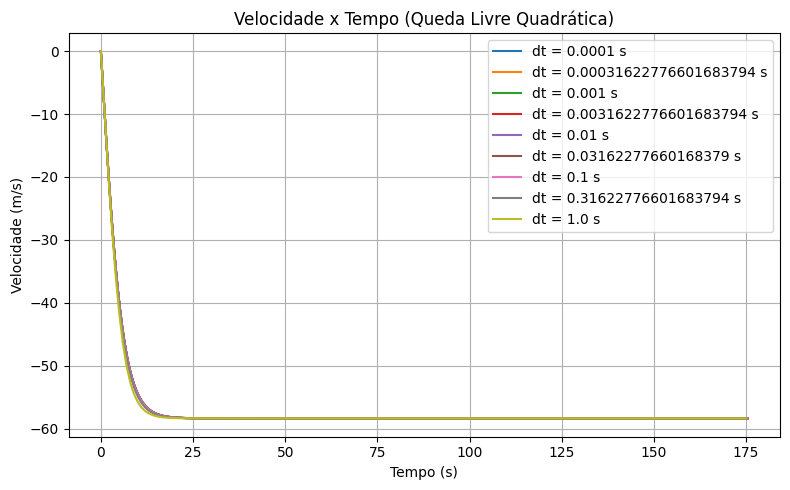

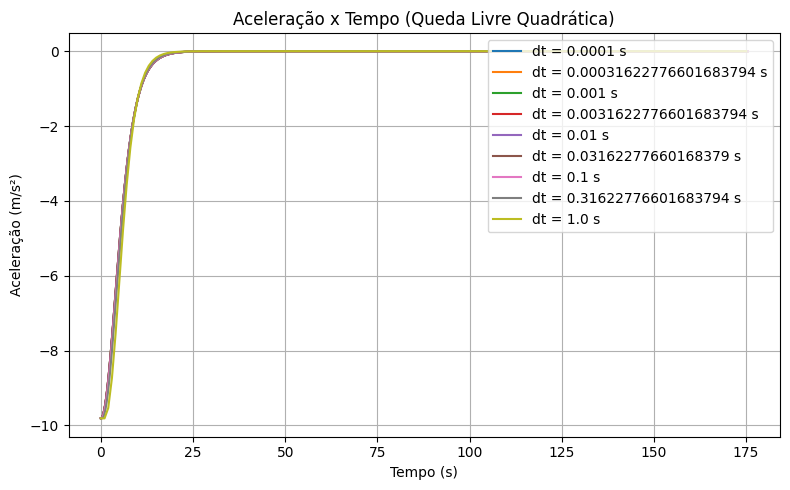

In [45]:
resultados_csv_quadratica = {}

for dt in dt_list:
    df_quadratica = simula_queda_livre_corpo_rigido_quadratica(
        H, V, g, dt, c
    )
    resultados_csv_quadratica[dt] = {
        't': df_quadratica['tempo'].tolist(),
        'x': df_quadratica['posicao'].tolist(),
        'v': df_quadratica['velocidade'].tolist(),
        'a': df_quadratica['aceleracao'].tolist()
    }
    nome_arquivo = f'saida_queda_livre_quadratica_dt_{str(dt).replace('.', '_')}.csv'
    salvar_dados(df_quadratica, output_corpo_rigido_quadratica_dir, nome_arquivo)


# Plotando os gráficos
plotar_grafico_posicao_tempo(
    resultados_csv_quadratica, dt_list, graficos_queda_livre_corpo_rigido_quadratica_dir,
    'Queda Livre Quadrática', 'grafico_posicao_tempo_quadratica_multidt.png'
)
plotar_grafico_velocidade_tempo(
    resultados_csv_quadratica, dt_list, graficos_queda_livre_corpo_rigido_quadratica_dir,
    'Queda Livre Quadrática', 'grafico_velocidade_tempo_quadratica_multidt.png'
)
plotar_grafico_aceleracao_tempo(
    resultados_csv_quadratica, dt_list, graficos_queda_livre_corpo_rigido_quadratica_dir,
    'Queda Livre Quadrática', 'grafico_aceleracao_tempo_quadratica_multidt.png'
)

### 2.3 Comparativo entre os Modelos

0.0001
Modelos disponíveis para comparação:
  Sem Resistência (Partícula): D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_particula\saida_queda_livre_dt_0_0001.csv
  Linear (Corpo Rígido): D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\linear\saida_queda_livre_linear_dt_0_0001.csv
  Quadrática (Corpo Rígido): D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\queda_livre_corpo_rigido\quadratica\saida_queda_livre_quadratica_dt_0_0001.csv


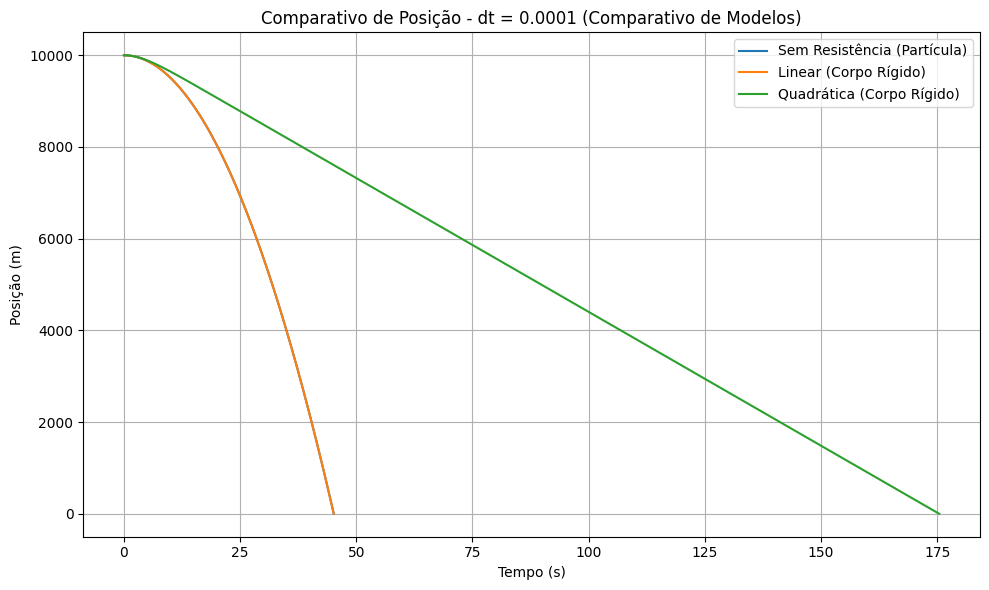

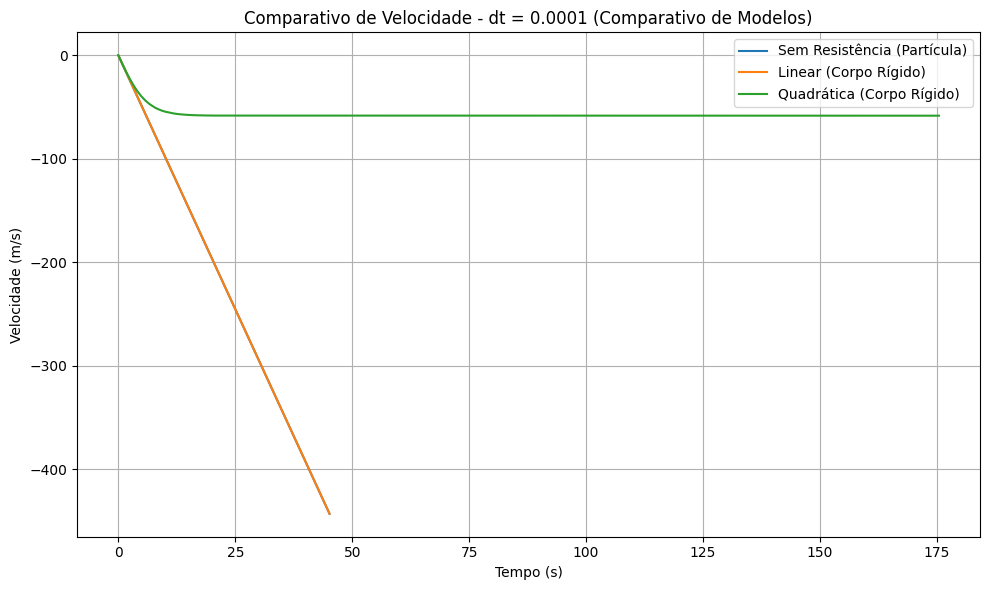

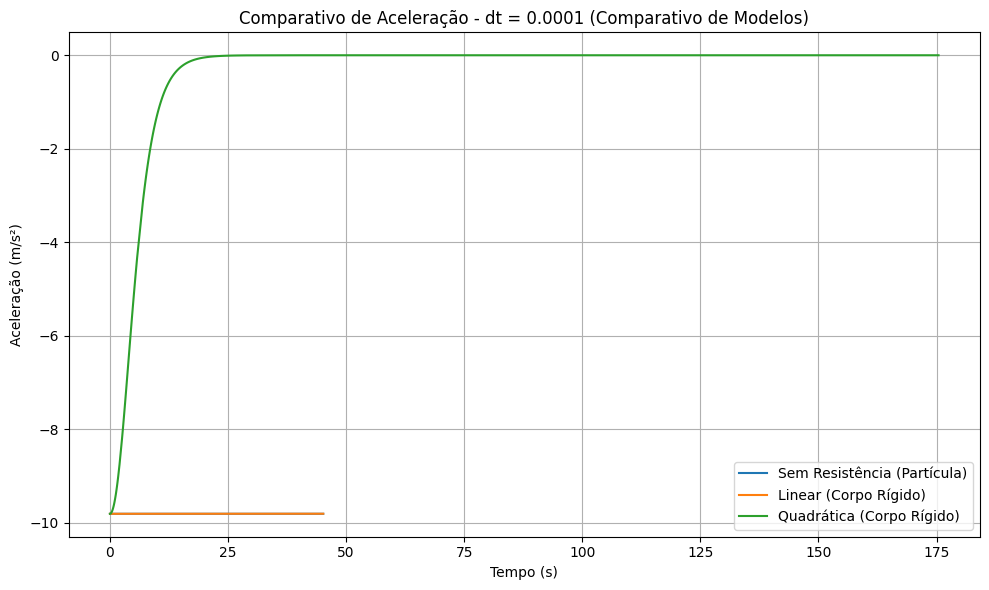

In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Defina o valor de dt e o diretório de saída dos gráficos
dt = 0.0001  # Ou dt = dt_list[0] se já definido
print(dt)

graficos_dir = graficos_comparativo_dir  # Use o diretório já definido no notebook
os.makedirs(graficos_dir, exist_ok=True)


output_queda_livre_particula_dir = output_dir / 'queda_livre_particula'
output_queda_livre_corpo_rigido_dir = output_dir / 'queda_livre_corpo_rigido'
output_corpo_rigido_linear_dir = output_queda_livre_corpo_rigido_dir / 'linear'
output_corpo_rigido_quadratica_dir = output_queda_livre_corpo_rigido_dir / 'quadratica'
# Caminhos dos arquivos para cada modelo (sem resistência do ar, apenas quadrática completa) 
modelos_arquivos = {
    'Sem Resistência (Partícula)': output_queda_livre_particula_dir / f'saida_queda_livre_dt_{str(dt).replace(".", "_")}.csv',
    'Linear (Corpo Rígido)': output_corpo_rigido_linear_dir / f'saida_queda_livre_linear_dt_{str(dt).replace(".", "_")}.csv',
    'Quadrática (Corpo Rígido)': output_corpo_rigido_quadratica_dir / f'saida_queda_livre_quadratica_dt_{str(dt).replace(".", "_")}.csv'
}

# Filtra apenas os arquivos que existem
def arquivos_existentes(modelos_dict):
    return {k: v for k, v in modelos_dict.items() if v.exists()}

modelos_arquivos_existentes = arquivos_existentes(modelos_arquivos)

if not modelos_arquivos_existentes:
    print("Nenhum arquivo de saída encontrado para o dt selecionado.")
else:
    print("Modelos disponíveis para comparação:")
    for modelo, caminho in modelos_arquivos_existentes.items():
        print(f"  {modelo}: {caminho}")

    # Funções de plotagem devem estar definidas anteriormente no notebook

    # Plotar posição
    plotar_comparativo_modelos_posicao(
        dt, modelos_arquivos_existentes, graficos_dir,
        titulo='Comparativo de Modelos',
        nome_arquivo='comparativo_posicao.png'
    )

    # Plotar velocidade
    plotar_comparativo_modelos_velocidade(
        dt, modelos_arquivos_existentes, graficos_dir,
        titulo='Comparativo de Modelos',
        nome_arquivo='comparativo_velocidade.png'
    )

    # Plotar aceleração
    plotar_comparativo_modelos_aceleracao(
        dt, modelos_arquivos_existentes, graficos_dir,
        titulo='Comparativo de Modelos',
        nome_arquivo='comparativo_aceleracao.png'
    )


### 2.4 Estudo da Acurácia no Valor Final da Velocidade

Agora vamos analisar a acurácia do valor final da velocidade ($v_{final}$) obtido numericamente para diferentes passos de tempo ($\Delta t$), comparando com o valor analítico esperado para cada caso (com e sem resistência do ar).

In [47]:
simula_acuracia_parametrizada(
    H=H,
    V=V,
    g=g,
    dt_list=dt_list,
    output_acuracia_dir=output_acuracia_dir,
    k=k,
    c=c
)

Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\acuracia_sem_resistencia.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\acuracia_com_resistencia_linear.csv
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\acuracia_com_resistencia_quadratica.csv


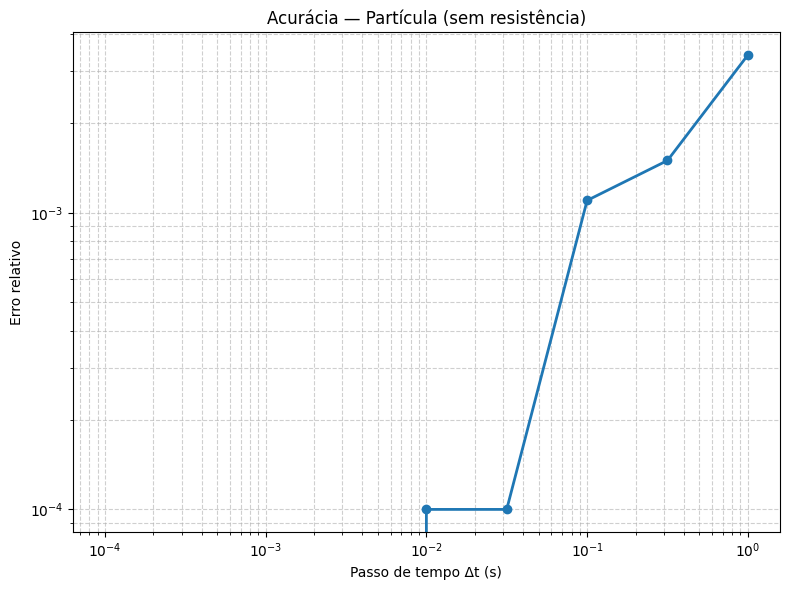

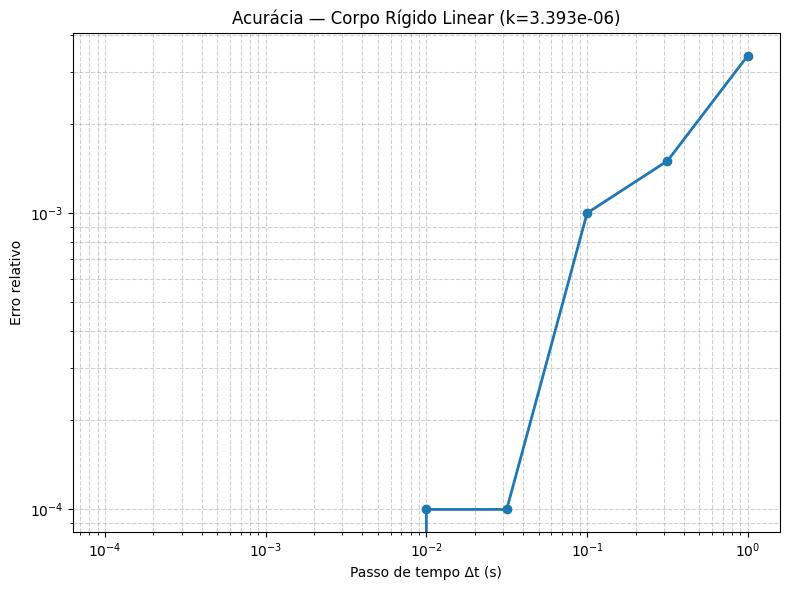

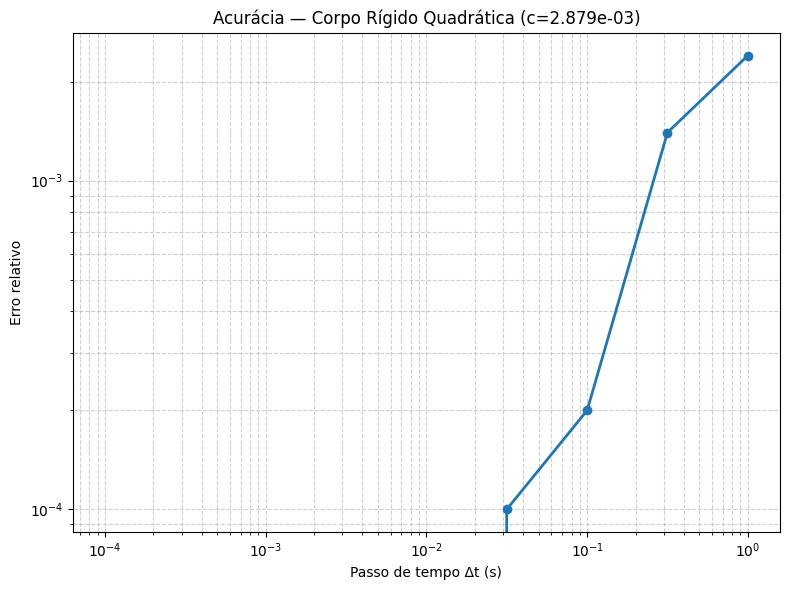

In [48]:
plotar_acuracia_dt(
    caminho_csv=output_acuracia_dir / 'acuracia_sem_resistencia.csv',
    titulo='Acurácia — Partícula (sem resistência)',
    nome_arquivo='acuracia_particula.png',
    graficos_dir=graficos_acuracia_dir
)

plotar_acuracia_dt(
    caminho_csv=output_acuracia_dir / 'acuracia_com_resistencia_linear.csv',
    titulo=f'Acurácia — Corpo Rígido Linear (k={k:.3e})',
    nome_arquivo='acuracia_linear.png',
    graficos_dir=graficos_acuracia_dir
)

plotar_acuracia_dt(
    caminho_csv=output_acuracia_dir / 'acuracia_com_resistencia_quadratica.csv',
    titulo=f'Acurácia — Corpo Rígido Quadrática (c={c:.3e})',
    nome_arquivo='acuracia_quadratica.png',
    graficos_dir=graficos_acuracia_dir
)

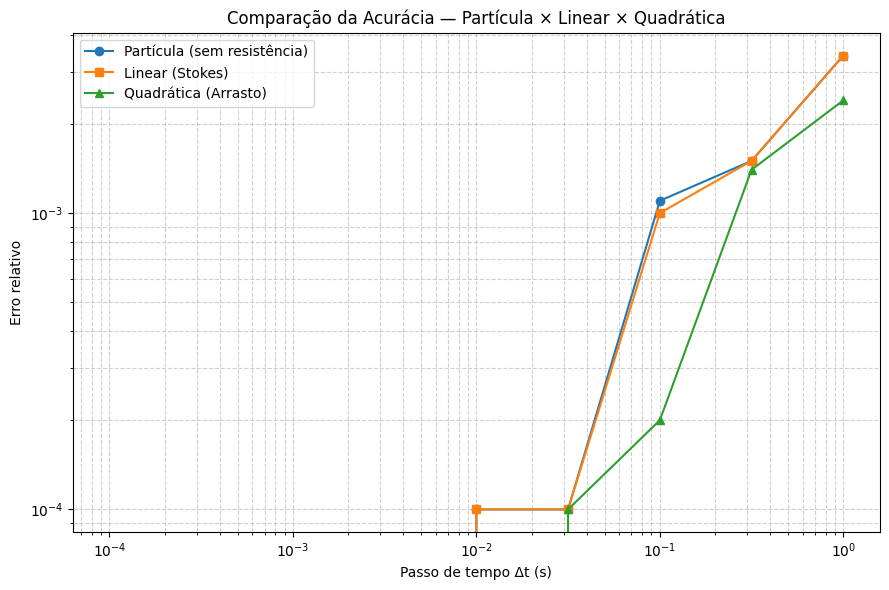

In [49]:
plotar_acuracia_comparativa(
    output_acuracia_dir,
    graficos_acuracia_dir,
    'acuracia_comparativa.png'
)

In [50]:
# Gera a tabela de acurácia
tabela = gerar_tabela_acuracia(output_acuracia_dir)

# Mostra no console
print(tabela)

# Salva no diretório de acurácia
salvar_dados(tabela, output_acuracia_dir, "tabela_acuracia.csv")

   dt (s)  Erro Partícula  Erro Linear  Erro Quadrática
0  0.0001          0.0000       0.0000           0.0000
1  0.0003          0.0000       0.0000           0.0000
2  0.0010          0.0000       0.0000           0.0000
3  0.0032          0.0000       0.0000           0.0000
4  0.0100          0.0001       0.0001           0.0000
5  0.0316          0.0001       0.0001           0.0001
6  0.1000          0.0011       0.0010           0.0002
7  0.3162          0.0015       0.0015           0.0014
8  1.0000          0.0034       0.0034           0.0024
Resultado salvo em: D:\GitHub\DoutoradoCefet\PrincipioModelagemMatematica\PraticaQuedaLIvre\src\dados\output\acuracia\tabela_acuracia.csv
